<a href="https://colab.research.google.com/github/Htethwk/vehicle-queue-monitor/blob/main/Computer_Vision_and_Wait_time.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-Powered Vehicle Queue Monitoring System

This project combines computer vision and agentic AI to monitor vehicle queues,
estimate congestion and wait times, and automatically recommend operational
actions when predefined thresholds are exceeded.

### System Flow

Video Feed
→ YOLOv8 Vehicle Detection
→ Queue Monitoring
→ Queue Metrics
→ AI Agent
→ Operational Alert

### Technologies

- Python
- YOLOv8 / Ultralytics
- OpenCV
- Pandas
- LangChain
- OpenAI API
- Google Colab



In [157]:
!pip install -q ultralytics opencv-python pandas matplotlib langchain langchain-openai

In [158]:
import os
import cv2
import glob
import getpass
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO
from IPython.display import Image, display

In [159]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [160]:
video_path = "/content/drive/MyDrive/VehicleQueueProject/video.mp4"
frames_dir = "/content/frames"

os.makedirs(frames_dir, exist_ok=True)

if not os.path.exists(video_path):
    raise FileNotFoundError(f"Video not found: {video_path}")

print("Video loaded successfully.")

Video loaded successfully.


In [161]:
#Queue Region of Interest (ROI)
FPS = 30
QUEUE_ZONE = np.array([
    (100, 300),
    (500, 300),
    (500, 600),
    (100, 600)
])
frames_dir = "/content/frames"

entry_times = {}
completed_waits = []
detections_list = []
results = []
prev_avg_wait = 0


In [162]:
def in_queue_zone(x, y, zone):
    return cv2.pointPolygonTest(zone, (x, y), False) >= 0



In [163]:
video_path = '/content/drive/MyDrive/VehicleQueueProject/video.mp4'
frames_dir = '/content/frames'
os.makedirs(frames_dir, exist_ok=True)


cap = cv2.VideoCapture(video_path)
frame_count = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break
    if frame_count % 5 == 0:  # save every 5th frame
        cv2.imwrite(os.path.join(frames_dir, f'frame_{frame_count}.jpg'), frame)
    frame_count += 1

cap.release()
print(f"Extracted {frame_count} frames")
print("Exists:", os.path.exists(video_path))

cap = cv2.VideoCapture(video_path)
print("Opened:", cap.isOpened())

Extracted 633 frames
Exists: True
Opened: True


## Vehicle Detection

YOLOv8 is used to identify vehicles in each video frame. The model detects
vehicle classes such as cars, buses, and trucks, which are then filtered
according to the defined queue region.

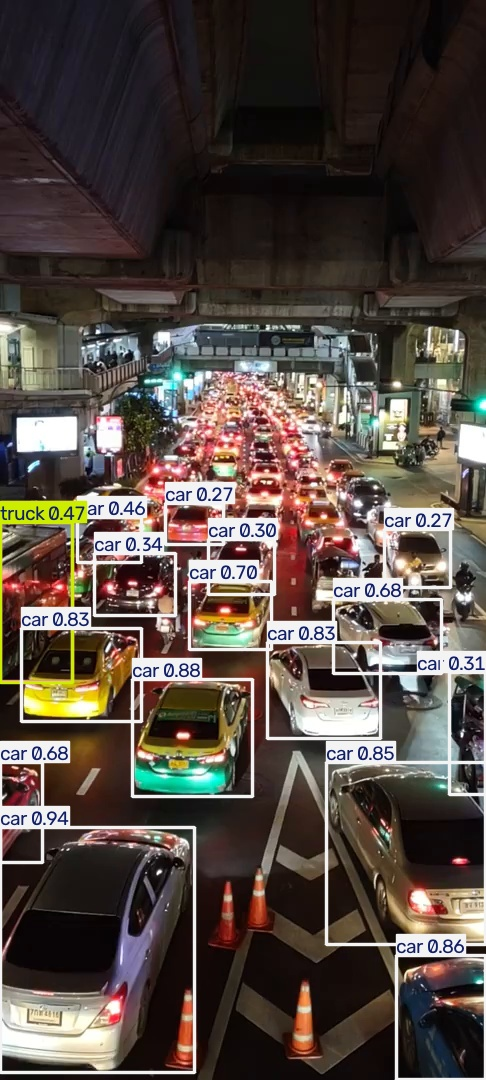

In [164]:
model = YOLO('yolov8s.pt')

frames_dir = '/content/frames'
image_path = os.path.join(frames_dir, 'frame_0.jpg')

output_dir = '/content/VehicleQueueProject'
os.makedirs(output_dir, exist_ok=True)

results = model(image_path, verbose=False)
output_path = os.path.join(output_dir, 'results.jpg')


results[0].save(output_path)
display(Image(filename=output_path))

In [165]:
frame_id = 0
entry_frames = {}
completed_waits = []
vehicle_counter = 0
dss_results = []
print(cap.isOpened())
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Run YOLO on the frame
    yolo_results = model.track(frame,persist=True,imgsz=960,verbose=False)

    for box in yolo_results[0].boxes:
      if box.id is None:
          continue

      x1, y1, x2, y2, = box.xyxy[0].tolist()
      score = float(box.conf[0])
      cls = int(box.cls[0])

      # vehicle classes only
      if int(cls) not in [2, 5, 7]:
          continue

      vehicle_id = int(box.id.item())

      cx = int((x1 + x2) / 2)
      cy = int((y1 + y2) / 2)

      # ENTER queue
      if vehicle_id not in entry_frames and cv2.pointPolygonTest(QUEUE_ZONE, (cx, cy), False) >= 0:
          entry_frames[vehicle_id] = frame_id


      if vehicle_id in entry_frames and cv2.pointPolygonTest(QUEUE_ZONE, (cx, cy), False) < 0:
          wait_time = (frame_id - entry_frames[vehicle_id]) / FPS
          completed_waits.append(wait_time)
          del entry_frames[vehicle_id]

    # DSS logic (once per frame)
    if entry_frames:
      current_waits = [
          (frame_id - entry_frame) / FPS
          for entry_frame in entry_frames.values()
      ]
      avg_wait = np.mean(current_waits)
    else:
      avg_wait = 0

    queue_length = len(entry_frames)

    if avg_wait > 15 or queue_length > 10:
      decision = "High congestion"
    elif avg_wait > 8 or queue_length > 5:
      decision = "Moderate congestion"
    else:
      decision = "Normal flow"

    dss_results.append({
    "index": len(dss_results),
    "avg_wait": avg_wait,
    "queue_length": queue_length,
    "decision": decision
})

    frame_id += 1


True


In [177]:
actual_times = [110, 95, 130, 80, 100]

if len(completed_waits) >= len(actual_times):
    estimated_times = completed_waits[:len(actual_times)]
    mae = np.mean(np.abs(np.array(estimated_times) - np.array(actual_times)))
    print(f"MAE: {mae:.2f} seconds")
else:
    print("Not enough completed waits to compute MAE")



Not enough completed waits to compute MAE


Index(['index', 'avg_wait', 'queue_length', 'decision'], dtype='object')
633


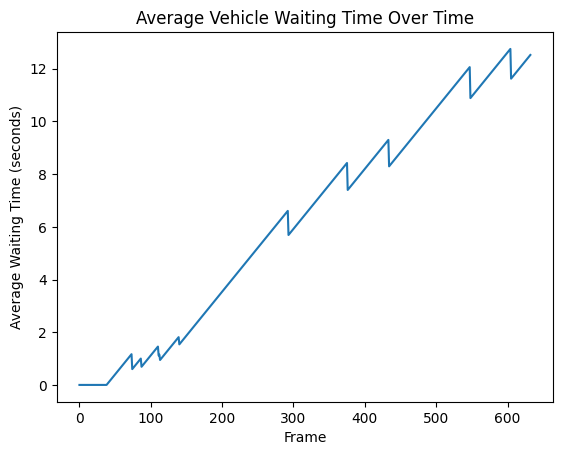

In [178]:
df = pd.DataFrame(dss_results)

print(df.columns)
print(len(dss_results))
plt.figure()
plt.plot(df["index"], df["avg_wait"])
plt.xlabel("Frame")
plt.ylabel("Average Waiting Time (seconds)")
plt.title("Average Vehicle Waiting Time Over Time")
plt.show()




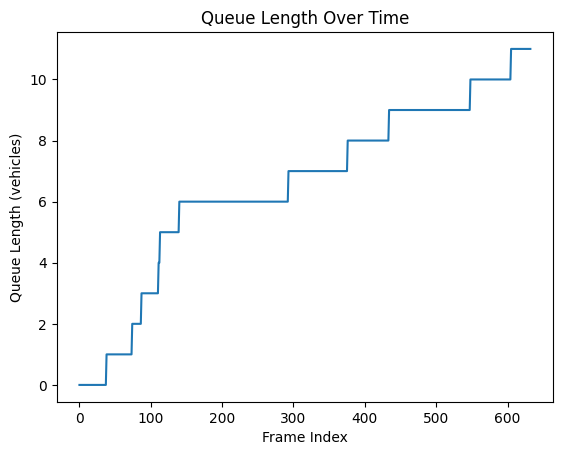

In [179]:
 # Plot queue length over frames
plt.figure()
plt.plot(df["index"], df["queue_length"])  # Use 'index' instead of 'frame'
plt.xlabel("Frame Index")
plt.ylabel("Queue Length (vehicles)")
plt.title("Queue Length Over Time")
plt.show()


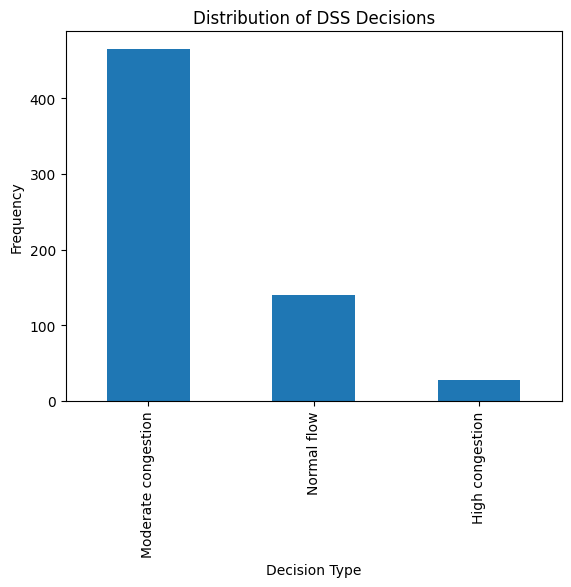

In [180]:
# Plot decision type frequency (bar chart)
df["decision"].value_counts().plot(kind="bar")
plt.xlabel("Decision Type")
plt.ylabel("Frequency")
plt.title("Distribution of DSS Decisions")
plt.show()


In [195]:
queue_metrics = df [["index","queue_length","avg_wait","decision"]].copy()

queue_metrics["avg_wait"] = queue_metrics["avg_wait"].round(2)

queue_metrics = queue_metrics.rename(columns=
 {"index": "frame",
  "queue_length": "vehicle_count",
  "avg_wait": "avg_wait_time_seconds",
  "decision": "congestion_status"
                                             })

queue_metrics.to_csv(
    "/content/drive/MyDrive/VehicleQueueProject/queue_metrics.csv",
    index=False
)

path = "/content/drive/MyDrive/VehicleQueueProject/queue_metrics.csv"
print("saved:", os.path.exists(path))
print(path)

saved: True
/content/drive/MyDrive/VehicleQueueProject/queue_metrics.csv


In [181]:
if "OPENAI_API_KEY" not in os.environ:
    os.environ["OPENAI_API_KEY"] = getpass.getpass("OpenAI API Key: ")

In [182]:
!cp /content/drive/MyDrive/VehicleQueueProject/* .

In [184]:
with open("requirements.txt", "w") as f:
    f.write("torch\nultralytics\nopencv-python\nmatplotlib\nnumpy\n")


In [185]:
print(df.columns)

latest_queue_length = int(df["queue_length"].iloc[-1])
latest_avg_wait = float(df["avg_wait"].iloc[-1])

print(f"Latest queue length: {latest_queue_length}")
print(f"Latest average wait time: {latest_avg_wait:.2f} seconds")
queue_length
df.tail(10)

Index(['index', 'avg_wait', 'queue_length', 'decision'], dtype='object')
Latest queue length: 11
Latest average wait time: 12.52 seconds


,index,avg_wait,queue_length,decision
623,623,12.224242,11,High congestion
624,624,12.257576,11,High congestion
625,625,12.290909,11,High congestion
626,626,12.324242,11,High congestion
627,627,12.357576,11,High congestion
628,628,12.390909,11,High congestion
629,629,12.424242,11,High congestion
630,630,12.457576,11,High congestion
631,631,12.490909,11,High congestion
632,632,12.524242,11,High congestion


In [187]:
from langchain.agents import create_agent
from langchain_core.tools import Tool
from langchain_openai import ChatOpenAI

def get_queue_telemetry():
  latest = df.iloc[-1]

  return {
      "vehicle_count": int(latest["queue_length"]),
      "avg_wait_time_seconds": round(float(latest["avg_wait"]), 2),
      "threshold_exceeded":latest["decision"]
  }


def trigger_operational_alert(message:str ):
  print(f"n\--- [Agent Action Executed] ---")
  print(f"Alert Status: Dispatched")
  print(f"Alert Message: {message}")
  print(f"--------------------------\n")
  return "Alert successfully sesnt to operations team"



tools = [
    Tool(
        name = "GetQueueTelemetry",
        func = lambda x: str(get_queue_telemetry()),
        description= "Retrives live vehicle count and average wait times  from YOLO8"

    ),

    Tool(
        name = "TriggerOperationalAlert",
        func = trigger_operational_alert,
        description= "Dispatches an automated operational alert when congetion or bottleneck occur"

    )
]

llm = ChatOpenAI(temperature=0, model_name="gpt-4o")
agent = create_agent(
    model=llm,
    tools=tools
)


query = """
Check current vehicle queue telemetry.
If the vehicle count exceeds 10 or the average wait time is high,
diagnose the situation and trigger an operational alert with recommended actions.
"""

response = agent.invoke({
    "messages": [
        {"role": "user", "content": query}
    ]
})

print(response["messages"][-1].content)

<>:16: SyntaxWarning: invalid escape sequence '\-'
<>:16: SyntaxWarning: invalid escape sequence '\-'
/tmp/ipykernel_744/3543261786.py:16: SyntaxWarning: invalid escape sequence '\-'
  print(f"n\--- [Agent Action Executed] ---")


n\--- [Agent Action Executed] ---
Alert Status: Dispatched
Alert Message: High vehicle count detected with 11 vehicles and an average wait time of 12.52 seconds. Recommended actions: 1. Increase the frequency of traffic signal changes to allow more vehicles to pass. 2. Deploy traffic management personnel to manually direct traffic if necessary. 3. Monitor the situation closely for any further escalation.
--------------------------

The vehicle queue telemetry indicates a high congestion situation with 11 vehicles and an average wait time of 12.52 seconds. An operational alert has been triggered with the following recommended actions:

1. Increase the frequency of traffic signal changes to allow more vehicles to pass.
2. Deploy traffic management personnel to manually direct traffic if necessary.
3. Monitor the situation closely for any further escalation.

The alert has been successfully sent to the operations team.


In [175]:
!git config --global user.name "htethwk"
!git config --global user.email "htethtetwinkhine.hhwk@gmail.com"

In [176]:
%cd /content
!git clone https://github.com/htethwk/vehicle-queue-monitor.git
%cd vehicle-queue-monitor

/content
fatal: destination path 'vehicle-queue-monitor' already exists and is not an empty directory.
/content/vehicle-queue-monitor
